In [1]:
import jupyter_black
import torch
import os
from torch import nn
import matplotlib.pyplot as plt
from pathlib import Path
from torchvision import datasets, transforms
from PIL import Image
from torch.utils.data import Dataset, DataLoader

jupyter_black.load()

In [2]:
device = "mps" if torch.backends.mps.is_available() else "CPU"
device

'mps'

## Getting the data for health/disease detection

In [3]:
# import kagglehub

# path = kagglehub.dataset_download("andresmgs/plantdec")
# print("Path to dataset files:", path)

In [4]:
# import shutil

# shutil.copytree(path, "Plant_project", dirs_exist_ok=True)
# print("Data successfully copied to your working folder!")

### fixing the data 

In [31]:
class CustomPlantDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        """
        Args:
            root_dir (Path/str): Path to the split folder (e.g., 'Plant_project_data/train')
            transform (callable, optional): Optional transform to be applied on a sample.
        """
        self.root_dir = Path(root_dir)
        self.images_dir = self.root_dir / "images"
        self.labels_dir = self.root_dir / "labels"

        # List all image files sorted so they align correctly
        self.image_files = sorted(
            [
                f
                for f in os.listdir(self.images_dir)
                if f.endswith((".jpg", ".jpeg", ".png"))
            ]
        )
        self.transform = transform

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        # 1. Get image path and load it
        img_name = self.image_files[idx]
        img_path = self.images_dir / img_name
        image = Image.open(img_path).convert("RGB")

        # 2. Get corresponding label file path
        label_name = img_name.rsplit(".", 1)[0] + ".txt"
        label_path = self.labels_dir / label_name

        # 3. Read the class ID from the label file (YOLO format: class_id x_center y_center width height)
        # We take the first integer on the first line as the classification label
        label = 0  # Default fallback
        if label_path.exists() and os.path.getsize(label_path) > 0:
            with open(label_path, "r") as f:
                first_line = f.readline().strip().split()
                if first_line:
                    label = int(first_line[0])  # Grab the class ID

        # 4. Apply any transformations
        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.long)

In [32]:
base_data_path = Path("Plant_project_data")

# 2. Append the subfolders
train_dir = base_data_path / "train"
valid_dir = base_data_path / "valid"
test_dir = base_data_path / "test"
data_transform = transforms.Compose(
    [
        transforms.Resize(size=(64, 64)),
        transforms.RandomHorizontalFlip(p=0.5),  # 50% chance to flip left/right
        transforms.RandomRotation(degrees=15),  # Randomly rotate by up to 15 degrees
        transforms.ColorJitter(brightness=0.1, contrast=0.1),
        transforms.ToTensor(),
    ]
)
doc_train_data = CustomPlantDataset(
    root_dir="Plant_project_data/train", transform=data_transform
)
doc_valid_data = CustomPlantDataset(
    root_dir="Plant_project_data/valid", transform=data_transform
)
doc_test_data = CustomPlantDataset(
    root_dir="Plant_project_data/test", transform=data_transform
)

In [33]:
BATCH_SIZE = 32
train_dataloader = DataLoader(
    dataset=doc_train_data, batch_size=BATCH_SIZE, shuffle=True
)
valid_dataloader = DataLoader(
    dataset=doc_valid_data, batch_size=BATCH_SIZE, shuffle=False
)
test_dataloader = DataLoader(
    dataset=doc_test_data, batch_size=BATCH_SIZE, shuffle=False
)

## Getting the data for species identification

In [8]:
# os.environ["KAGGLEHUB_CACHE"] = str(Path("").absolute() / "leafsnap_data")

# 2. Run the download (it will go straight into the folder above)
# path = kagglehub.dataset_download("vandat2601/leafsnap-processed")
# print("Downloaded straight to:", path)

# 3. See what folders are inside it
# print("\nContents of your local folder:")
# print(os.listdir(path))
!pip install tqdm

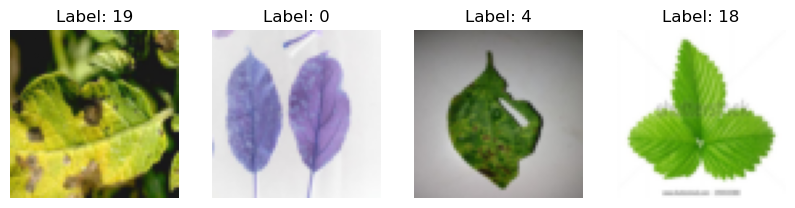

In [9]:
images, labels = next(iter(train_dataloader))

# 2. Set up a grid to plot
plt.figure(figsize=(10, 5))
for i in range(4):
    plt.subplot(1, 4, i + 1)

    # PyTorch images are [Channels, Height, Width], but matplotlib needs [Height, Width, Channels]
    # We use .permute() to swap the dimensions
    img = images[i].permute(1, 2, 0).numpy()

    plt.imshow(img)
    plt.title(f"Label: {labels[i].item()}")
    plt.axis("off")

plt.show()

In [10]:
class PlantHealthClassifierV0(nn.Module):
    """
    Model architecture replicating TinyVGG.
    """

    def __init__(self, input_shape: int, hidden_units: int, output_shape: int) -> None:
        super().__init__()
        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(
                in_channels=input_shape,
                out_channels=hidden_units,
                kernel_size=3,
                stride=1,
                padding=1,
            ),
            nn.ReLU(),
            nn.Conv2d(
                in_channels=hidden_units,
                out_channels=hidden_units,
                kernel_size=3,
                stride=1,
                padding=1,
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(hidden_units, hidden_units, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(hidden_units, hidden_units, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            # If input is 64x64, after two MaxPool2d(kernel_size=2), it becomes 16x16
            nn.Linear(in_features=hidden_units * 16 * 16, out_features=output_shape),
        )

    def forward(self, x: torch.Tensor):
        return self.classifier(self.conv_block_2(self.conv_block_1(x)))


model_0 = PlantHealthClassifierV0(input_shape=3, hidden_units=20, output_shape=38).to(
    device
)

In [24]:
def train_test_step(
    model: nn.Module, train_dataloader, test_dataloader, loss_fn, optimizer, device
):
    model.train()
    train_loss, train_acc = 0, 0

    for batch, (X, y) in enumerate(tqdm(train_dataloader, desc="Batches", leave=False)):
        X, y = X.to(device), y.to(device)

        y_pred = model(X)

        loss = loss_fn(y_pred, y)
        train_loss += loss.item()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        y_pred_class = y_pred.argmax(dim=1)
        train_acc += (y_pred_class == y).sum().item() / len(y_pred)

    # Adjust metrics to get average per batch
    train_loss /= len(train_dataloader)
    train_acc /= len(train_dataloader)

    # evalualting
    model.eval()
    test_loss, test_acc = 0, 0
    with torch.inference_mode():
        for (
            batch,
            (X, y),
        ) in enumerate(test_dataloader):
            X, y = X.to(device), y.to(device)

            test_pred_logits = model(X)
            loss = loss_fn(test_pred_logits, y)
            test_loss += loss.item()
            test_pred_labels = test_pred_logits.argmax(dim=1)
            test_acc += (test_pred_labels == y).sum().item() / len(test_pred_labels)

        test_loss /= len(test_dataloader)
        test_acc /= len(test_dataloader)
        return train_loss, train_acc, test_loss, test_acc

# Training the model for health/disease detection

In [12]:
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.01)
train_test_step(model_0, train_dataloader, test_dataloader, loss_fn, optimizer, device)

(3.5049447205758866, 0.06388142174432497, 3.4429046511650085, 0.046875)

In [13]:
from tqdm.auto import tqdm


def EvalModel(EPOCHS, model, loss_fn, optimizer, device):
    EPOCHS = EPOCHS

    # 2. Start the loop
    for epoch in tqdm(range(EPOCHS), desc="Training Progress"):

        # Call your function, passing the clean objects
        train_loss, train_acc, val_loss, val_acc = train_test_step(
            model=model,
            train_dataloader=train_dataloader,
            test_dataloader=valid_dataloader,
            loss_fn=loss_fn,
            optimizer=optimizer,
            device=device,
        )
        print(
            f"Epoch:{epoch}|Train Loss: {train_loss:.4f} | Train Acc: {train_acc*100:.2f}%|Val Loss: {val_loss:.4f} | Val Acc: {val_acc*100:.2f}%"
        )


EvalModel(5, model_0, loss_fn, optimizer, device)

Training Progress:   0%|          | 0/5 [00:00<?, ?it/s]

Epoch:0|Train Loss: 3.3124 | Train Acc: 6.52%|Val Loss: 3.2567 | Val Acc: 7.25%
Epoch:1|Train Loss: 3.2906 | Train Acc: 6.41%|Val Loss: 3.2161 | Val Acc: 9.46%
Epoch:2|Train Loss: 3.2622 | Train Acc: 7.92%|Val Loss: 3.2062 | Val Acc: 8.55%
Epoch:3|Train Loss: 3.2418 | Train Acc: 7.97%|Val Loss: 3.2097 | Val Acc: 6.82%
Epoch:4|Train Loss: 3.2288 | Train Acc: 8.79%|Val Loss: 3.1780 | Val Acc: 9.12%


# Improving the model
## Changing the optimizer to Adam

In [14]:
optimizer_1 = torch.optim.Adam(params=model_0.parameters(), lr=0.01)
EvalModel(5, model_0, loss_fn, optimizer_1, device)

Training Progress:   0%|          | 0/5 [00:00<?, ?it/s]

Epoch:0|Train Loss: 3.3429 | Train Acc: 6.75%|Val Loss: 3.2499 | Val Acc: 6.97%
Epoch:1|Train Loss: 3.2828 | Train Acc: 7.02%|Val Loss: 3.2490 | Val Acc: 7.13%
Epoch:2|Train Loss: 3.2757 | Train Acc: 7.24%|Val Loss: 3.2299 | Val Acc: 7.13%
Epoch:3|Train Loss: 3.2833 | Train Acc: 7.07%|Val Loss: 3.2601 | Val Acc: 7.13%
Epoch:4|Train Loss: 3.2928 | Train Acc: 6.86%|Val Loss: 3.2553 | Val Acc: 4.60%


## increasing model capacity

In [15]:
model_1 = PlantHealthClassifierV0(input_shape=3, hidden_units=64, output_shape=38).to(
    device
)
optimizer_2 = torch.optim.Adam(params=model_1.parameters(), lr=0.01)

train_test_step(
    model_1, train_dataloader, test_dataloader, loss_fn, optimizer_2, device
)
EvalModel(5, model_1, loss_fn, optimizer_2, device)

Training Progress:   0%|          | 0/5 [00:00<?, ?it/s]

Epoch:0|Train Loss: 3.2857 | Train Acc: 7.18%|Val Loss: 3.2438 | Val Acc: 7.13%
Epoch:1|Train Loss: 3.2740 | Train Acc: 7.71%|Val Loss: 3.2795 | Val Acc: 7.13%
Epoch:2|Train Loss: 3.2703 | Train Acc: 7.98%|Val Loss: 3.2534 | Val Acc: 6.85%
Epoch:3|Train Loss: 3.2401 | Train Acc: 8.64%|Val Loss: 3.2601 | Val Acc: 7.13%
Epoch:4|Train Loss: 3.1509 | Train Acc: 10.14%|Val Loss: 3.2854 | Val Acc: 7.98%


## changing learning rate

In [16]:
optimizer_3 = torch.optim.Adam(params=model_1.parameters(), lr=0.001)

train_test_step(
    model_1, train_dataloader, test_dataloader, loss_fn, optimizer_3, device
)
EvalModel(5, model_1, loss_fn, optimizer_3, device)

Training Progress:   0%|          | 0/5 [00:00<?, ?it/s]

Epoch:0|Train Loss: 2.8222 | Train Acc: 18.40%|Val Loss: 3.6110 | Val Acc: 10.54%
Epoch:1|Train Loss: 2.7750 | Train Acc: 18.97%|Val Loss: 3.7512 | Val Acc: 9.40%
Epoch:2|Train Loss: 2.6947 | Train Acc: 21.32%|Val Loss: 3.7319 | Val Acc: 9.69%
Epoch:3|Train Loss: 2.5333 | Train Acc: 26.36%|Val Loss: 4.0638 | Val Acc: 9.97%
Epoch:4|Train Loss: 2.3738 | Train Acc: 30.17%|Val Loss: 4.1654 | Val Acc: 10.54%


In [17]:
## Reassigning model
class PlantHealthClassifierV1(nn.Module):

    def __init__(self, input_shape: int, hidden_units: int, output_shape: int) -> None:
        super().__init__()
        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(
                in_channels=input_shape,
                out_channels=hidden_units,
                kernel_size=3,
                stride=1,
                padding=1,
            ),
            nn.BatchNorm2d(hidden_units),
            nn.ReLU(),
            nn.Conv2d(
                in_channels=hidden_units,
                out_channels=hidden_units,
                kernel_size=3,
                stride=1,
                padding=1,
            ),
            nn.BatchNorm2d(hidden_units),  # Added to both convs for maximum stability
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(
                in_channels=hidden_units,
                out_channels=hidden_units * 2,
                kernel_size=3,
                padding=1,
            ),
            nn.ReLU(),
            nn.Conv2d(
                in_channels=hidden_units * 2,
                out_channels=hidden_units * 2,
                kernel_size=3,
                padding=1,
            ),
            nn.BatchNorm2d(hidden_units * 2),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            # If input is 64x64, after two MaxPool2d(kernel_size=2), it becomes 16x16
            nn.Linear(in_features=(hidden_units * 2) * 16 * 16, out_features=256),
            nn.ReLU(),
            nn.Dropout(p=0.3),  # Prevents overfitting
            nn.Linear(in_features=256, out_features=output_shape),
        )

    def forward(self, x: torch.Tensor):
        return self.classifier(self.conv_block_2(self.conv_block_1(x)))


model_2 = PlantHealthClassifierV1(input_shape=3, hidden_units=32, output_shape=38).to(
    device
)

In [18]:
optimizer_4 = torch.optim.Adam(params=model_2.parameters(), lr=0.001)
train_test_step(
    model_2, train_dataloader, test_dataloader, loss_fn, optimizer_4, device
)
EvalModel(15, model_2, loss_fn, optimizer_4, device)

Training Progress:   0%|          | 0/15 [00:00<?, ?it/s]

Epoch:0|Train Loss: 3.2520 | Train Acc: 9.20%|Val Loss: 3.1012 | Val Acc: 10.82%
Epoch:1|Train Loss: 3.1827 | Train Acc: 9.12%|Val Loss: 3.0168 | Val Acc: 11.39%
Epoch:2|Train Loss: 3.1185 | Train Acc: 9.27%|Val Loss: 3.0290 | Val Acc: 11.11%
Epoch:3|Train Loss: 3.0652 | Train Acc: 10.05%|Val Loss: 3.0823 | Val Acc: 10.85%
Epoch:4|Train Loss: 3.0328 | Train Acc: 11.60%|Val Loss: 2.9805 | Val Acc: 12.27%
Epoch:5|Train Loss: 3.0140 | Train Acc: 11.57%|Val Loss: 2.9444 | Val Acc: 11.42%
Epoch:6|Train Loss: 2.9756 | Train Acc: 12.01%|Val Loss: 2.9665 | Val Acc: 11.99%
Epoch:7|Train Loss: 2.9543 | Train Acc: 12.88%|Val Loss: 2.9557 | Val Acc: 12.90%
Epoch:8|Train Loss: 2.9274 | Train Acc: 13.60%|Val Loss: 2.9616 | Val Acc: 12.30%
Epoch:9|Train Loss: 2.8896 | Train Acc: 14.84%|Val Loss: 2.8520 | Val Acc: 14.58%
Epoch:10|Train Loss: 2.8706 | Train Acc: 14.36%|Val Loss: 2.9620 | Val Acc: 12.27%
Epoch:11|Train Loss: 2.8487 | Train Acc: 15.36%|Val Loss: 3.0570 | Val Acc: 12.90%
Epoch:12|Train Lo

## try to make new model with LazyConv2d and increase hidden units

In [34]:
class PlantHealthClassifierV2(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int) -> None:
        super().__init__()
        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(
                in_channels=input_shape,
                out_channels=hidden_units,
                kernel_size=3,
                stride=1,
                padding=1,
            ),
            nn.BatchNorm2d(hidden_units),
            nn.ReLU(),
            nn.Conv2d(
                in_channels=hidden_units,
                out_channels=hidden_units,
                kernel_size=3,
                stride=1,
                padding=1,
            ),
            nn.BatchNorm2d(hidden_units),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(
                in_channels=hidden_units,
                out_channels=hidden_units * 2,
                kernel_size=3,
                padding=1,
            ),
            nn.ReLU(),
            nn.Conv2d(
                in_channels=hidden_units * 2,
                out_channels=hidden_units * 2,
                kernel_size=3,
                padding=1,
            ),
            nn.BatchNorm2d(hidden_units * 2),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),  # Compresses spatial dimensions to 1x1
            nn.Flatten(),
            # FIX: Total features entering here is now just channels (hidden_units * 2)
            nn.Linear(in_features=hidden_units * 2, out_features=256),
            nn.ReLU(),
            nn.Dropout(p=0.4),  # Slightly bumped up to handle 512 units
            nn.Linear(in_features=256, out_features=output_shape),
        )

    def forward(self, x: torch.Tensor):
        return self.classifier(self.conv_block_2(self.conv_block_1(x)))


model_3 = PlantHealthClassifierV2(input_shape=3, hidden_units=128, output_shape=38).to(
    device
)

In [35]:
optimizer_5 = torch.optim.Adam(params=model_3.parameters(), lr=0.001)
train_test_step(
    model_3, train_dataloader, test_dataloader, loss_fn, optimizer_5, device
)

Batches:   0%|          | 0/62 [00:00<?, ?it/s]

(3.2807760969285042,
 0.08829898446833931,
 3.1868602633476257,
 0.09817708333333333)

In [21]:
EvalModel(5, model_3, loss_fn, optimizer_5, device)

Training Progress:   0%|          | 0/5 [00:00<?, ?it/s]

Epoch:0|Train Loss: 3.1236 | Train Acc: 10.06%|Val Loss: 3.0451 | Val Acc: 11.23%
Epoch:1|Train Loss: 3.0898 | Train Acc: 10.29%|Val Loss: 3.0328 | Val Acc: 13.19%
Epoch:2|Train Loss: 3.0508 | Train Acc: 11.79%|Val Loss: 3.0275 | Val Acc: 13.98%
Epoch:3|Train Loss: 3.0213 | Train Acc: 13.07%|Val Loss: 2.9996 | Val Acc: 12.27%
Epoch:4|Train Loss: 3.0068 | Train Acc: 13.27%|Val Loss: 3.0214 | Val Acc: 13.72%


## Increase epoch to 15

In [22]:
EvalModel(15, model_3, loss_fn, optimizer_5, device)

Training Progress:   0%|          | 0/15 [00:00<?, ?it/s]

Epoch:0|Train Loss: 3.0055 | Train Acc: 12.73%|Val Loss: 3.0819 | Val Acc: 13.41%
Epoch:1|Train Loss: 2.9845 | Train Acc: 12.23%|Val Loss: 3.0179 | Val Acc: 14.61%
Epoch:2|Train Loss: 2.9315 | Train Acc: 14.29%|Val Loss: 2.9735 | Val Acc: 12.59%
Epoch:3|Train Loss: 2.9199 | Train Acc: 14.66%|Val Loss: 3.1901 | Val Acc: 12.36%
Epoch:4|Train Loss: 2.8823 | Train Acc: 16.18%|Val Loss: 3.0201 | Val Acc: 15.23%
Epoch:5|Train Loss: 2.8783 | Train Acc: 16.79%|Val Loss: 3.0451 | Val Acc: 15.71%
Epoch:6|Train Loss: 2.8331 | Train Acc: 16.66%|Val Loss: 3.0392 | Val Acc: 14.80%
Epoch:7|Train Loss: 2.8002 | Train Acc: 18.06%|Val Loss: 4.7868 | Val Acc: 11.14%
Epoch:8|Train Loss: 2.7648 | Train Acc: 19.49%|Val Loss: 2.8443 | Val Acc: 18.81%
Epoch:9|Train Loss: 2.7625 | Train Acc: 19.01%|Val Loss: 3.1997 | Val Acc: 12.71%
Epoch:10|Train Loss: 2.6945 | Train Acc: 21.34%|Val Loss: 3.0607 | Val Acc: 19.12%
Epoch:11|Train Loss: 2.6395 | Train Acc: 21.95%|Val Loss: 2.7733 | Val Acc: 21.96%
Epoch:12|Train

In [23]:
model_3.state_dict()

OrderedDict([('conv_block_1.0.weight',
              tensor([[[[ 1.8632e-01,  6.0886e-02,  1.4074e-01],
                        [ 1.0219e-01,  1.2906e-01, -5.1439e-03],
                        [ 6.3826e-02, -8.5616e-02,  3.4059e-02]],
              
                       [[-2.2842e-03,  1.6465e-02, -1.6585e-01],
                        [-1.1909e-01, -1.9494e-01, -5.9790e-02],
                        [ 6.3714e-02,  1.8969e-02, -1.3126e-01]],
              
                       [[ 1.7933e-01,  9.2380e-02,  4.5168e-02],
                        [ 1.3722e-01,  6.4709e-02, -1.4286e-01],
                        [ 5.4520e-02, -9.0824e-02, -1.9273e-01]]],
              
              
                      [[[ 1.6358e-02,  1.4888e-01,  1.8509e-01],
                        [ 2.2739e-02,  1.9220e-01,  1.2031e-01],
                        [-1.2790e-01, -1.0869e-01,  6.7584e-02]],
              
                       [[-1.7772e-01, -1.2740e-01, -2.0788e-01],
                        [ 1.7613e-01

## Increase epoch to 40

In [36]:
EvalModel(40, model_3, loss_fn, optimizer_5, device)

Training Progress:   0%|          | 0/40 [00:00<?, ?it/s]

Batches:   0%|          | 0/62 [00:00<?, ?it/s]

Epoch:0|Train Loss: 3.1253 | Train Acc: 9.88%|Val Loss: 3.0934 | Val Acc: 10.85%


Batches:   0%|          | 0/62 [00:00<?, ?it/s]

Epoch:1|Train Loss: 3.0908 | Train Acc: 11.05%|Val Loss: 3.0427 | Val Acc: 14.10%


...

Epoch:37|Train Loss: 2.1947 | Train Acc: 32.11%|Val Loss: 2.5083 | Val Acc: 30.66%


Batches:   0%|          | 0/62 [00:00<?, ?it/s]

Epoch:38|Train Loss: 2.2026 | Train Acc: 32.69%|Val Loss: 2.4673 | Val Acc: 27.42%


Batches:   0%|          | 0/62 [00:00<?, ?it/s]

Epoch:39|Train Loss: 2.1748 | Train Acc: 33.13%|Val Loss: 2.6110 | Val Acc: 26.09%


In [37]:
MODEL_NAME = "best_model_plant_disease_40_epochs.pth"
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(obj=model_3.state_dict(), f=MODEL_SAVE_PATH)

Saving model to: models/best_model_plant_disease_40_epochs.pth
